## I- Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

path = "/content/drive/MyDrive/datasets programming coursework/"
files = ["3.csv", "4.csv", "5.csv", "6.csv", "7.csv"]

Mounted at /content/drive


## II- Part (a): Data Claning and Pre-processing

**1- Loading and cleaning data**

In [23]:
cols_a = [
    "Year", "Month", "DayofMonth", "DayOfWeek",
    "CRSDepTime", "ArrDelay", "DepDelay", "Cancelled"
]

hour_delay_list = []
day_delay_list = []

for file in files:
    df = pd.read_csv(path + file, usecols=cols_a, low_memory=False)

    # removing cancelled flights
    df = df[df["Cancelled"] == 0]
    # removing missing values
    df = df.dropna(subset=["ArrDelay", "DepDelay", "CRSDepTime", "DayOfWeek"])
    # creating hour variable
    df["Hour"] = df["CRSDepTime"] // 100
    # keeping valid hours only
    df = df[(df["Hour"] >= 0) & (df["Hour"] <= 23)]
    # yearly aggregation by departure hour
    hour_delay = df.groupby(["Year", "Hour"], as_index=False)["ArrDelay"].mean()
    # yearly aggregation by day of week
    day_delay = df.groupby(["Year", "DayOfWeek"], as_index=False)["ArrDelay"].mean()

    hour_delay_list.append(hour_delay)
    day_delay_list.append(day_delay)

    del df, hour_delay, day_delay

**2- Combining Datasets**

In [28]:
hour_delay = pd.concat(hour_delay_list, ignore_index=True)
day_delay = pd.concat(day_delay_list, ignore_index=True)

hour_delay = hour_delay.sort_values(["Year", "Hour"]).reset_index(drop=True)
day_delay = day_delay.sort_values(["Year", "DayOfWeek"]).reset_index(drop=True)

## III. Part (a): Delay Analysis

**1- Extracting best hour & best day**

In [25]:
best_hour = hour_delay.loc[hour_delay.groupby("Year")["ArrDelay"].idxmin()].reset_index(drop=True)
best_day = day_delay.loc[day_delay.groupby("Year")["ArrDelay"].idxmin()].reset_index(drop=True)

print("Best hour each year:")
display(best_hour)

print("Best day each year:")
display(best_day)

Best hour each year:


,Year,Hour,ArrDelay
0,2003,3,-17.428571
1,2004,4,-7.259259
2,2005,5,-1.415424
3,2006,5,-0.350445
4,2007,3,0.726154


Best day each year:


,Year,DayOfWeek,ArrDelay
0,2003,6,0.490321
1,2004,6,2.649383
2,2005,6,3.301072
3,2006,6,5.169126
4,2007,6,5.846600


**2- Main visualisations**

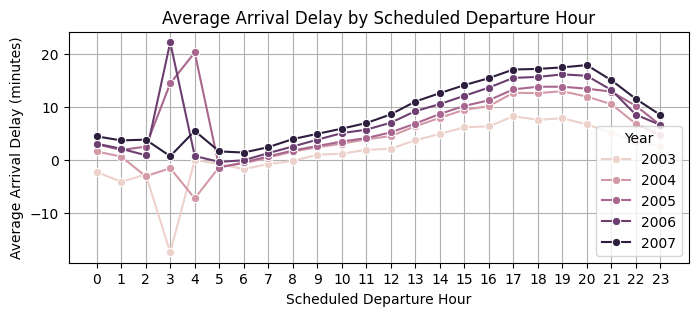

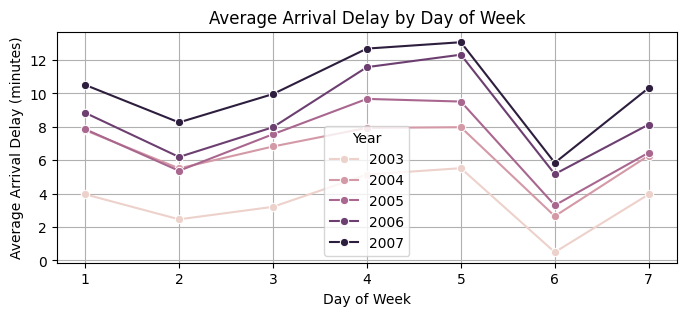

In [42]:
plt.figure(figsize=(8, 3))
sns.lineplot(data=hour_delay, x="Hour", y="ArrDelay", hue="Year", marker="o")
plt.title("Average Arrival Delay by Scheduled Departure Hour")
plt.xlabel("Scheduled Departure Hour")
plt.ylabel("Average Arrival Delay (minutes)")
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 3))
sns.lineplot(data=day_delay, x="DayOfWeek", y="ArrDelay", hue="Year", marker="o")
plt.title("Average Arrival Delay by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Arrival Delay (minutes)")
plt.xticks(range(1, 8))
plt.grid(True)
plt.show()

**3- Supporting visualisations**

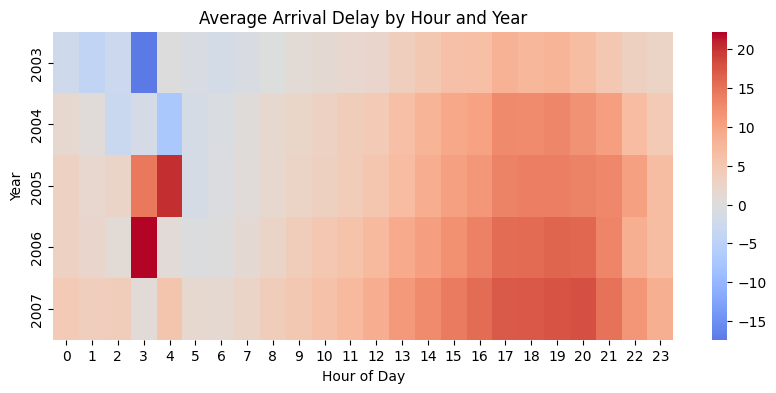

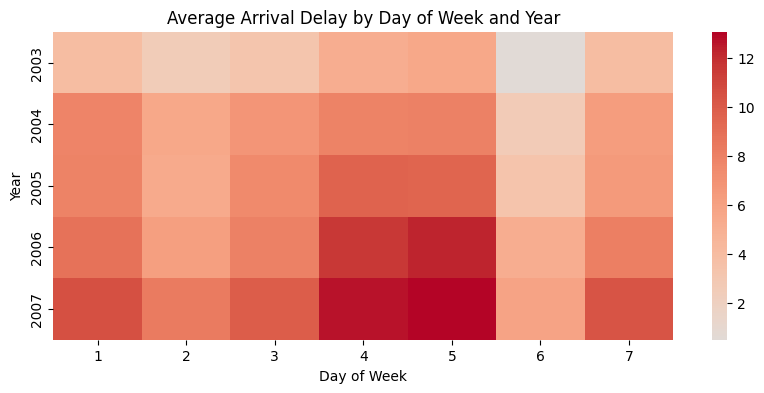

In [45]:
pivot_table = hour_delay.pivot(index="Year", columns="Hour", values="ArrDelay")

plt.figure(figsize=(10, 4))
sns.heatmap(pivot_table, cmap="coolwarm", center=0, annot=False)
plt.title("Average Arrival Delay by Hour and Year")
plt.xlabel("Hour of Day")
plt.ylabel("Year")
plt.show()

pivot_day = day_delay.pivot(index="Year", columns="DayOfWeek", values="ArrDelay")

plt.figure(figsize=(10, 4))
sns.heatmap(pivot_day, cmap="coolwarm", center=0, annot=False)
plt.title("Average Arrival Delay by Day of Week and Year")
plt.xlabel("Day of Week")
plt.ylabel("Year")
plt.show()

## IV. Part (b): Data Cleaning and Pre-processing

**1- Loading required flight columns**

In [30]:
cols_b = ["Year", "TailNum", "ArrDelay", "DepDelay", "Cancelled"]

**2- Reading yearly files and cleaning flights**

In [31]:
flights_list = []

for file in files:
    df = pd.read_csv(path + file, usecols=cols_b, low_memory=False)

    df = df[df["Cancelled"] == 0]
    df = df.dropna(subset=["ArrDelay", "DepDelay"])
    df["TotalDelay"] = df["ArrDelay"] + df["DepDelay"]

    flights_list.append(df)
    del df

flights = pd.concat(flights_list, ignore_index=True)
del flights_list

**3- Loading and cleaning plane data**

In [32]:
planes = pd.read_csv(path + "plane-data.csv", low_memory=False)
planes = planes.rename(columns={"tailnum": "TailNum"})
planes = planes[["TailNum", "year"]]
planes["year"] = pd.to_numeric(planes["year"], errors="coerce")

**4- Merge and create plane age**

In [37]:
flights_planes = flights.merge(planes, on="TailNum", how="left")
flights_planes["PlaneAge"] = flights_planes["Year"] - flights_planes["year"]

flights_planes = flights_planes[
    (flights_planes["PlaneAge"] >= 0) &
    (flights_planes["PlaneAge"] <= 40)
].copy()

age_delay_year = flights_planes.groupby(["Year", "PlaneAge"], as_index=False)["ArrDelay"].mean()

## V. Part (b): Aircraft Age Analysis

**1- Main visualisation**

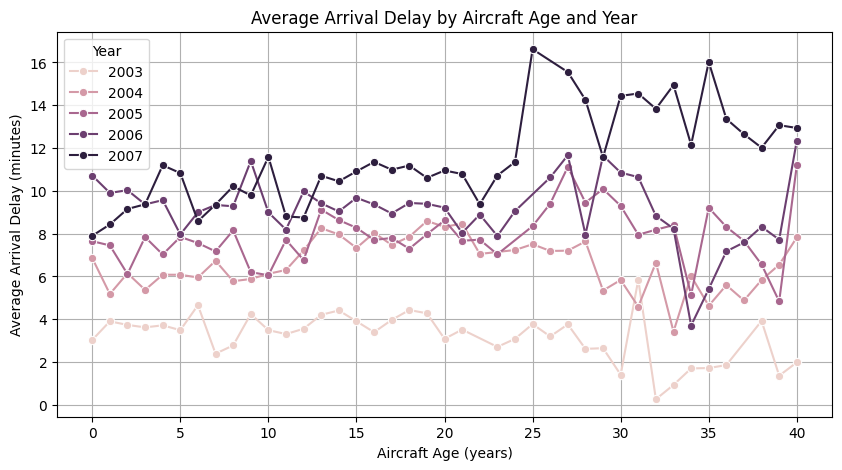

In [43]:
plt.figure(figsize=(10,5))
sns.lineplot(data=age_delay_year, x="PlaneAge", y="ArrDelay", hue="Year", marker="o")
plt.title("Average Arrival Delay by Aircraft Age and Year")
plt.xlabel("Aircraft Age (years)")
plt.ylabel("Average Arrival Delay (minutes)")
plt.grid(True)
plt.show()

**2- Supporting visualisation 1**

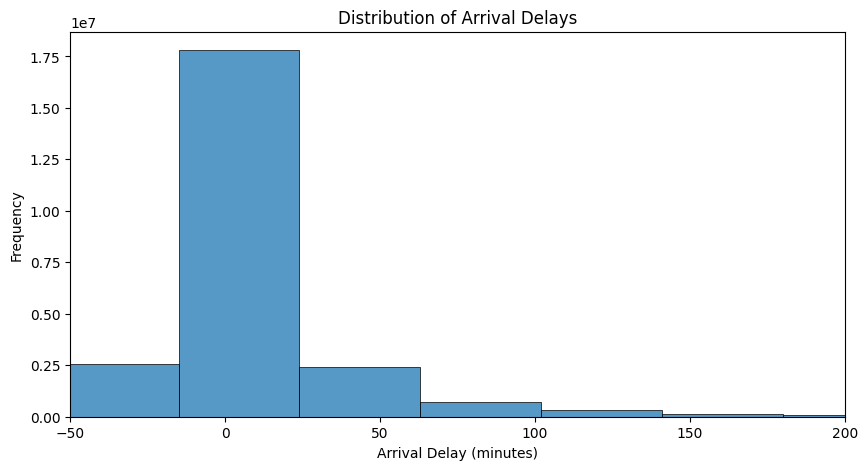

In [46]:
plt.figure(figsize=(10,5))
sns.histplot(flights_planes["ArrDelay"], bins=100)

plt.xlim(-50, 200)
plt.title("Distribution of Arrival Delays")
plt.xlabel("Arrival Delay (minutes)")
plt.ylabel("Frequency")
plt.show()

**3- Supporting visualisation 2**

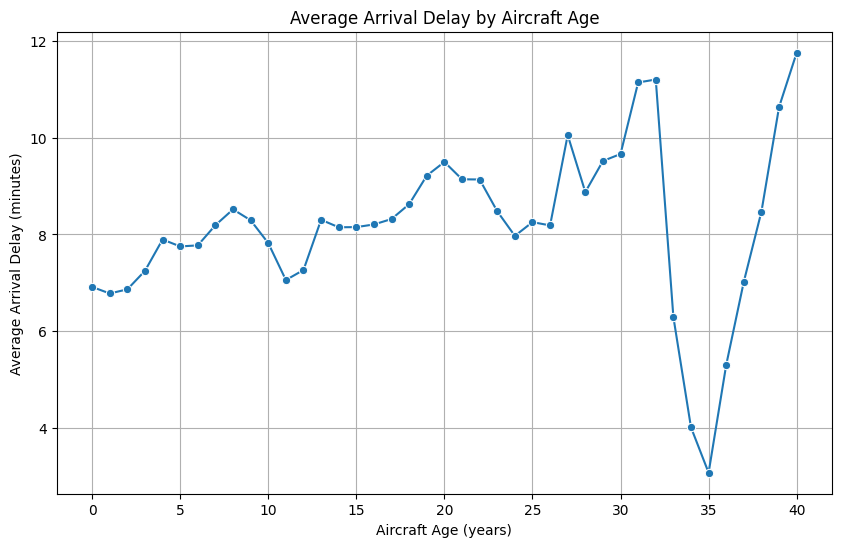

In [40]:
plt.figure(figsize=(10,6))
sns.lineplot(data=age_delay, x="PlaneAge", y="ArrDelay", marker="o")

plt.title("Average Arrival Delay by Aircraft Age")
plt.xlabel("Aircraft Age (years)")
plt.ylabel("Average Arrival Delay (minutes)")
plt.grid(True)
plt.show()

## VI. Part (c): Data Cleaning and Pre-processing

**1- Imports**

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler

**2- Selecting relevant columns**

In [3]:
cols_c_report = [
    "Year", "Month", "DayOfWeek",
    "CRSDepTime", "CRSArrTime",
    "Distance", "DepDelay",
    "UniqueCarrier", "Diverted", "Cancelled"
]

## VII. Part (c): Logistic Regression Modelling of Flight Diversions

**1- Fitting the model and extracting coefficients**

In [4]:
results_c = []
coef_by_year = {}

for file in files:
    df = pd.read_csv(path + file, usecols=cols_c_report, low_memory=False)

    # basic cleaning
    df = df[df["Cancelled"] == 0]
    df = df.dropna(subset=[
        "Month", "DayOfWeek", "CRSDepTime", "CRSArrTime",
        "Distance", "DepDelay", "UniqueCarrier", "Diverted"
    ])
    # creating hour variables
    df["DepHour"] = df["CRSDepTime"] // 100
    df["ArrHour"] = df["CRSArrTime"] // 100
    # keeping only valid hours
    df = df[(df["DepHour"] <= 23) & (df["ArrHour"] <= 23)]
    # year
    year_value = int(df["Year"].iloc[0])
    # keeping all diverted flights + sample non-diverted flights
    diverted_df = df[df["Diverted"] == 1]
    non_diverted_df = df[df["Diverted"] == 0]

    if len(diverted_df) == 0:
        print(f"No diverted flights found for {year_value}, skipped.")
        continue

    non_div_sample = non_diverted_df.sample(
        n=min(len(non_diverted_df), max(20000, 20 * len(diverted_df))),
        random_state=42
    )
    df_model = pd.concat([diverted_df, non_div_sample], axis=0).sample(frac=1, random_state=42)

    X = df_model[["Month", "DayOfWeek", "DepHour", "ArrHour", "Distance", "DepDelay"]]
    y = df_model["Diverted"]
    model = LogisticRegression(max_iter=1000)
    model.fit(X, y)
    coef = pd.Series(model.coef_[0], index=X.columns)
    # saving coefficients in dictionary
    coef_by_year[year_value] = coef.sort_values()
    # saving long-format results
    for var, value in coef.items():
        results_c.append({
            "Year": year_value,
            "Variable": var,
            "Coefficient": value
        })

    del df, diverted_df, non_diverted_df, non_div_sample, df_model, X, y, model, coef

**2- Saving the coefficients table**

In [10]:
coef_df_report = pd.DataFrame(results_c)
coef_df_report = coef_df_report.sort_values(["Year", "Coefficient"])
coef_df_report.to_csv(path + "coef_df_report.csv", index=False)
print("Coefficient table saved successfully.")

Coefficient table saved successfully.


**3- Visualising one coefficient chart per year**

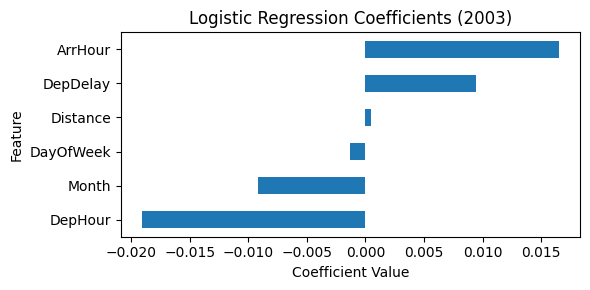

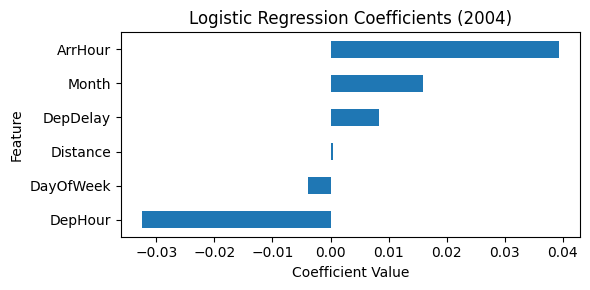

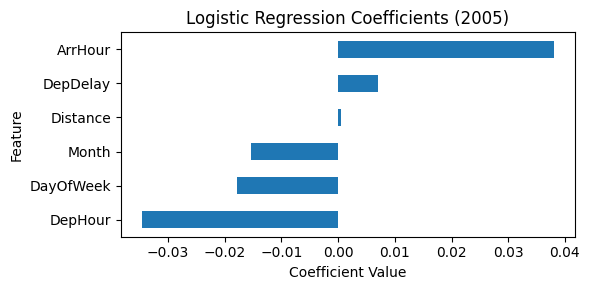

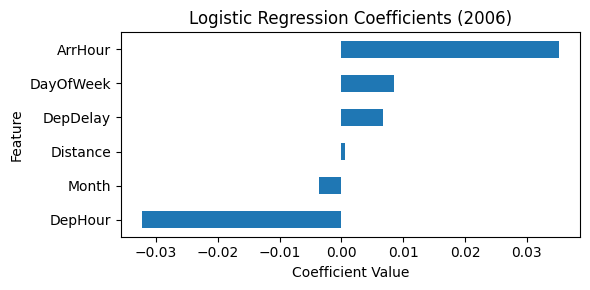

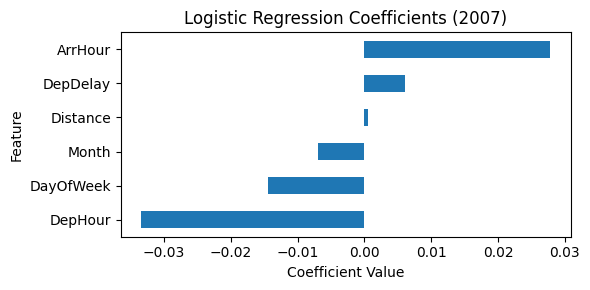

In [44]:
for year, coef in sorted(coef_by_year.items()):
    plt.figure(figsize=(6, 3))
    coef.plot(kind="barh")
    plt.title(f"Logistic Regression Coefficients ({year})")
    plt.xlabel("Coefficient Value")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

**4- Building the coefficient table**

In [12]:
tables_by_year = {}

for year in sorted(coef_df_report["Year"].unique()):
    year_table = coef_df_report[coef_df_report["Year"] == year].copy()
    year_table = year_table.sort_values("Coefficient")
    tables_by_year[year] = year_table

**5- Displaying one coefficient table per year**

In [13]:
for year in sorted(tables_by_year.keys()):
    print(f"\nCoefficients table for {year}")
    display(tables_by_year[year].reset_index(drop=True))


Coefficients table for 2003


,Year,Variable,Coefficient
0,2003,DepHour,-0.019084
1,2003,Month,-0.009199
2,2003,DayOfWeek,-0.001337
3,2003,Distance,0.000451
4,2003,DepDelay,0.009435
5,2003,ArrHour,0.016527



Coefficients table for 2004


,Year,Variable,Coefficient
0,2004,DepHour,-0.032519
1,2004,DayOfWeek,-0.003955
2,2004,Distance,0.000442
3,2004,DepDelay,0.008395
4,2004,Month,0.015995
5,2004,ArrHour,0.039391



Coefficients table for 2005


,Year,Variable,Coefficient
0,2005,DepHour,-0.034658
1,2005,DayOfWeek,-0.017808
2,2005,Month,-0.015330
3,2005,Distance,0.000471
4,2005,DepDelay,0.007081
5,2005,ArrHour,0.038058



Coefficients table for 2006


,Year,Variable,Coefficient
0,2006,DepHour,-0.032310
1,2006,Month,-0.003597
2,2006,Distance,0.000567
3,2006,DepDelay,0.006713
4,2006,DayOfWeek,0.008558
5,2006,ArrHour,0.035212



Coefficients table for 2007


,Year,Variable,Coefficient
0,2007,DepHour,-0.033367
1,2007,DayOfWeek,-0.014387
2,2007,Month,-0.006886
3,2007,Distance,0.000553
4,2007,DepDelay,0.006077
5,2007,ArrHour,0.027786


## VIII. Part (c): Carrier Diversion Rates

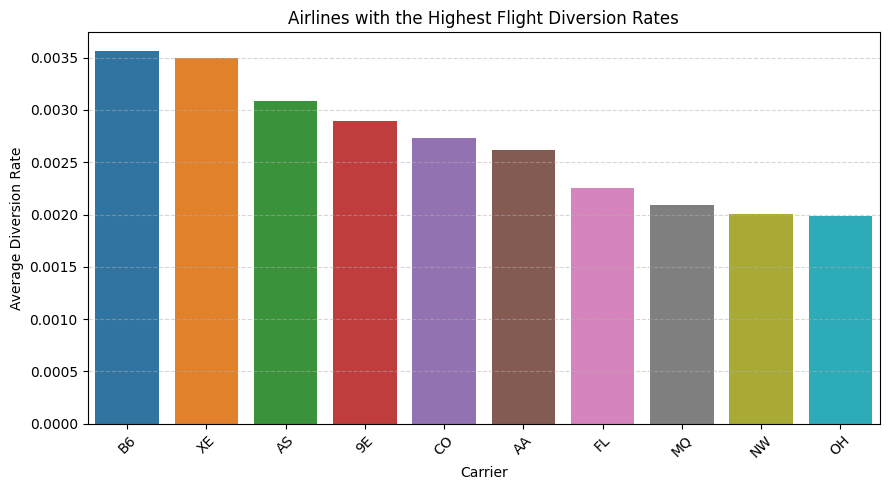

In [41]:
cols_carrier = ["Year", "UniqueCarrier", "Diverted", "Cancelled"]

carrier_list = []

for file in files:
    df = pd.read_csv(path + file, usecols=cols_carrier, low_memory=False)
    df = df[df["Cancelled"] == 0]
    carrier_list.append(df)

carrier_df = pd.concat(carrier_list, ignore_index=True)
del carrier_list

carrier_diversion = carrier_df.groupby("UniqueCarrier")["Diverted"].mean().sort_values(ascending=False)
top_carriers = carrier_diversion.head(10)

plt.figure(figsize=(9,5))
sns.barplot(
    x=top_carriers.index,
    y=top_carriers.values,
    hue=top_carriers.index,
    dodge=False,
    legend=False
)
plt.title("Airlines with the Highest Flight Diversion Rates")
plt.xlabel("Carrier")
plt.ylabel("Average Diversion Rate")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()